<a href="https://colab.research.google.com/github/2303A52352/EXPLAINABLE-AI/blob/main/final%20lab%20exam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
from google.colab import files
uploaded = files.upload()

import pandas as pd

# Replace filename with your uploaded file name
df = pd.read_csv(list(uploaded.keys())[0])
df.head()


Saving compiled solar irradiance India.csv to compiled solar irradiance India (1).csv


,States,Latitude,Longitude,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sept,Oct,Nov,Dec,Annual
0,ANDAMAN AND NICOBAR,11.667026,92.735983,5.06,5.88,6.23,6.20,4.62,4.22,4.31,4.39,4.44,4.92,4.70,4.60,4.964167
1,ANDHRA PRADESH,14.750429,78.570026,5.07,5.93,6.35,6.62,6.27,5.36,4.71,4.76,4.99,4.86,4.53,4.42,5.322500
2,ARUNACHAL PRADESH,27.100399,93.616601,3.05,3.10,3.32,3.35,3.72,3.56,3.70,3.97,3.59,3.85,3.53,3.13,3.489167
3,ASSAM,26.749981,94.216667,3.61,4.22,4.69,4.59,4.67,4.47,4.31,4.40,4.29,4.22,3.99,3.60,4.255000
4,BIHAR,25.785414,87.479973,3.15,4.35,5.39,5.77,5.67,4.90,4.33,4.45,4.37,4.49,4.01,3.19,4.505833


In [11]:
# ==============================
# PREPROCESSING
# ==============================

import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Identify column types
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("Numeric columns:", list(numeric_cols))
print("Categorical columns:", list(categorical_cols))

# Impute numeric (mean)
num_imputer = SimpleImputer(strategy='mean')
df[numeric_cols] = num_imputer.fit_transform(df[numeric_cols])

# Impute categorical (mode)
cat_imputer = SimpleImputer(strategy='most_frequent')
df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])

# Label Encoding for categorical columns
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print("\nDataset after cleaning:")
df.head()


Numeric columns: ['Latitude', 'Longitude', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sept', 'Oct', 'Nov', 'Dec', 'Annual']
Categorical columns: ['States']

Dataset after cleaning:


,States,Latitude,Longitude,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sept,Oct,Nov,Dec,Annual
0,0,11.667026,92.735983,5.06,5.88,6.23,6.20,4.62,4.22,4.31,4.39,4.44,4.92,4.70,4.60,4.964167
1,1,14.750429,78.570026,5.07,5.93,6.35,6.62,6.27,5.36,4.71,4.76,4.99,4.86,4.53,4.42,5.322500
2,2,27.100399,93.616601,3.05,3.10,3.32,3.35,3.72,3.56,3.70,3.97,3.59,3.85,3.53,3.13,3.489167
3,3,26.749981,94.216667,3.61,4.22,4.69,4.59,4.67,4.47,4.31,4.40,4.29,4.22,3.99,3.60,4.255000
4,4,25.785414,87.479973,3.15,4.35,5.39,5.77,5.67,4.90,4.33,4.45,4.37,4.49,4.01,3.19,4.505833


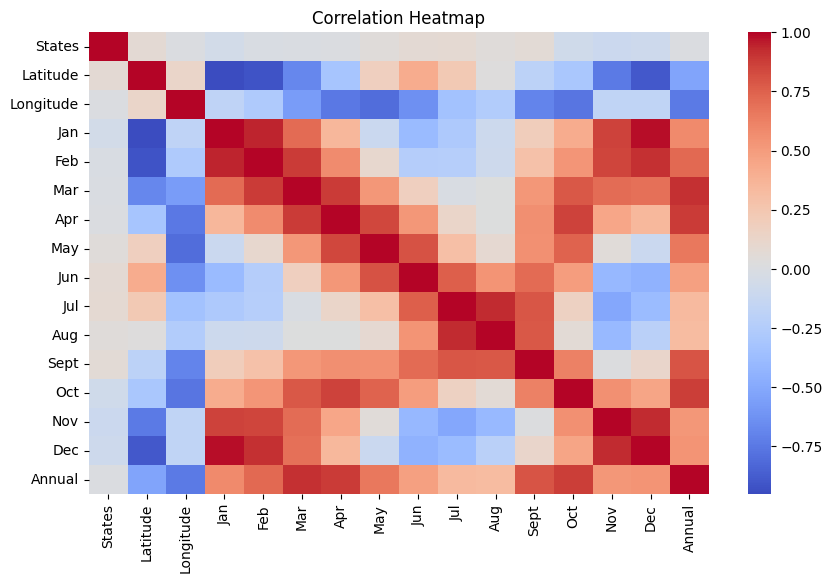

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [14]:
import pandas as pd

df = pd.read_csv("/content/compiled solar irradiance India (1).csv")
df.columns


Index(['States', 'Latitude', 'Longitude', 'Jan', 'Feb', 'Mar', 'Apr', 'May',
       'Jun', 'Jul', 'Aug', 'Sept', 'Oct', 'Nov', 'Dec', 'Annual'],
      dtype='object')

In [15]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

model = RandomForestClassifier()
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print("\nClassification Report:\n", classification_report(y_test, pred))


Accuracy: 0.75

Classification Report:
               precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       1.00      0.50      0.67         2
           2       0.75      0.75      0.75         4

    accuracy                           0.75         8
   macro avg       0.81      0.75      0.74         8
weighted avg       0.79      0.75      0.74         8



In [17]:
from imblearn.over_sampling import SMOTE

sm = SMOTE()
X_res, y_res = sm.fit_resample(X_train, y_train)

print("After SMOTE:", X_res.shape, y_res.shape)


After SMOTE: (30, 6) (30,)


In [18]:
model_smote = RandomForestClassifier()
model_smote.fit(X_res, y_res)

pred2 = model_smote.predict(X_test)

print("Accuracy After SMOTE:", accuracy_score(y_test, pred2))
print("\nClassification Report After SMOTE:\n", classification_report(y_test, pred2))


Accuracy After SMOTE: 0.75

Classification Report After SMOTE:
               precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       1.00      0.50      0.67         2
           2       0.75      0.75      0.75         4

    accuracy                           0.75         8
   macro avg       0.81      0.75      0.74         8
weighted avg       0.79      0.75      0.74         8



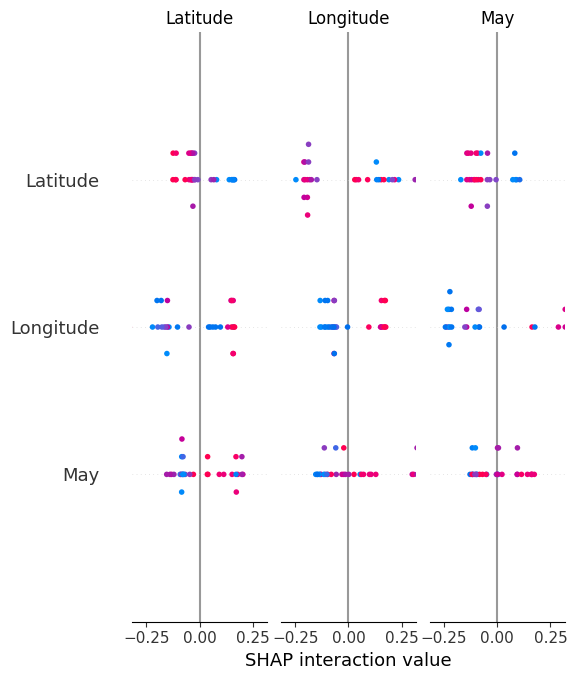

In [19]:
import shap
import numpy as np

explainer = shap.TreeExplainer(model_smote)
shap_values = explainer.shap_values(X_res)

# FIX: handle multiclass / binary / regression
if isinstance(shap_values, list):
    shap_summary_values = np.mean([np.abs(sv) for sv in shap_values], axis=0)
else:
    shap_summary_values = shap_values

shap.summary_plot(shap_summary_values, X_res, feature_names=X.columns)
